# Guía Teórica y Práctica: Auto-LM con FLAML

## 1.Fundamentos Teóricos: ¿Qué es el AutoML?

El AutoML (Automated Machine Learning) representa una evolución crítica en el campo de la ciencia de datos. Su objetivo no es eliminar al científico de datos, sino automatizar el proceso iterativo de experimentación.

**El Problema: El "Ensayo y Error" Tradicional**

Cuando entrenamos modelos manualmente (usando scikit-learn estándar), nos enfrentamos a dos desafíos principales:

1. Selección del Algoritmo: ¿Es mejor un Random Forest, un SVM o un Gradient Boosting para mis datos específicos?

2. Optimización de Hiperparámetros: Ajustar parámetros como la profundidad de los árboles, la tasa de aprendizaje o la regularización es un proceso de búsqueda exhaustiva que consume mucho tiempo.

**La Solución: Automatización mediante AutoML**

El AutoML automatiza la descubrimiento de los mejores modelos y sus hiperparámetros. En esencia, utiliza algoritmos de optimización para explorar el espacio de configuraciones posibles y seleccionar el modelo que maximiza la métrica objetivo (por ejemplo, accuracy o F1-score) dentro de un presupuesto de tiempo dado.

**¿Por qué usamos FLAML en lugar de Auto-Sklearn?**

Hasta hace poco, auto-sklearn era el estándar académico. Sin embargo, para nuestra clase utilizaremos FLAML (A Fast and Lightweight AutoML library) de Microsoft por tres razones críticas:

1. **Compatibilidad:** auto-sklearn tiene dependencias muy antiguas que fallan en entornos modernos (Python 3.12). FLAML es compatible y eficiente.

2. **Eficiencia de Recursos:** Mientras que otras librerías consumen muchísima RAM y tiempo, FLAML encuentra modelos competitivos en segundos.

3. **Versatilidad:** Soporta desde modelos clásicos hasta algoritmos de última generación como XGBoost o LightGBM de forma nativa.

## 2.Preparación del Entorno
Primero, instalamos la librería. En una infraestructura de Big Data real, la compatibilidad y la ligereza son clave.

In [1]:
# Instalamos las librerías que te faltan de una vez
!pip install pandas numpy seaborn matplotlib scikit-learn "flaml[automl]" --quiet
# Instalamos flaml, que es ligero y no requiere reiniciar el kernel en Python 3.12
#!pip install flaml --quiet

from IPython.display import clear_output
clear_output()
print("Entorno de FLAML configurado correctamente.")

Entorno de FLAML configurado correctamente.


Antes de continuar, y para que el colab quede limpio, cargaremos las librerías a usar.

In [ ]:
# 1. Librerías de Manipulación de Datos
import pandas as pd
import numpy as np

# 2. Librerías de Visualización Estadística
import seaborn as sns
import matplotlib.pyplot as plt

# 3. Librerías de Machine Learning (Scikit-Learn)
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 4. Motor de AutoML
from flaml import AutoML

# Configuración visual para mejorar la estética de los gráficos en el Notebook
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore') # Silenciamos warnings para una lectura limpia

print("Librerías importadas y entorno listo.")

## 3.Trabajos previos al Auto ML


### A) Carga y Análisis Exploratorio de Datos (EDA)

Vamos a usar el dataset de **iris** ya conocido de la librería de sklearn.datasets. Esta fase es fundamental. Antes de cualquier proceso de automatización, el científico de datos debe comprender la distribución, la dimensionalidad y las correlaciones de las variables predictoras (features) y su relación con la variable objetivo (target).

#### 1. Carga de los datos desde scikit-learn

In [3]:
# El dataset Iris es un problema multiclase con 3 especies y 4 medidas físicas.
data = load_iris()
print(data.DESCR)

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Mostramos las primeras 5 filas para verificar la carga
print("Primeras filas del dataset:")
display(df.head())

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


#### 2. Descripción estadística

In [4]:
# Fundamental para detectar escalas distintas en las variables (importante para el escalado).
print("--- Resumen Estadístico del Dataset ---")
display(df.describe())

--- Resumen Estadístico del Dataset ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


**Comentario:** Observamos si hay diferencias de escala entre las variables.

- Si una variable tiene rangos mucho mayores, será necesaria una normalización.

#### 3. Visualización de la relación entre variables (Pairplot)

<Figure size 1000x800 with 0 Axes>

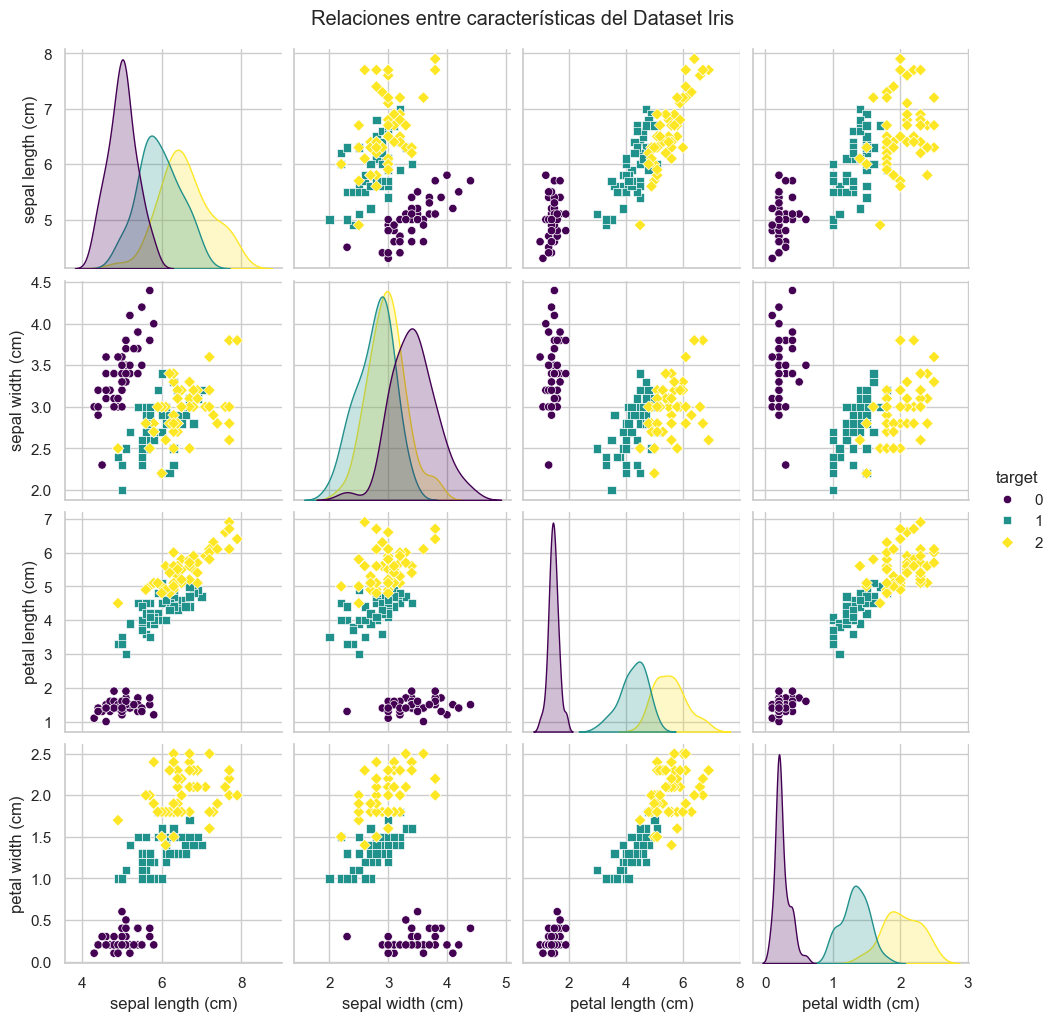

In [5]:
# Esta visualización permite identificar rápidamente qué variables separan mejor las clases (especies de flores).
# Pairplot muestra gráficos de dispersión entre todas las combinaciones de variables
# hue='target' colorea los puntos según la especie, facilitando ver la separación
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='target', palette='viridis', markers=["o", "s", "D"])
plt.suptitle('Relaciones entre características del Dataset Iris', y=1.02)
plt.show()

**Interpretación:**

- Si las nubes de puntos de colores están separadas, el modelo tendrá más facilidad para clasificar. Fijaos cómo algunas combinaciones (ej. pétalo vs sépalo) hacen que las especies sean fácilmente distinguibles.

#### 4. Visualización de la Matriz de Correlación (Heatmap)

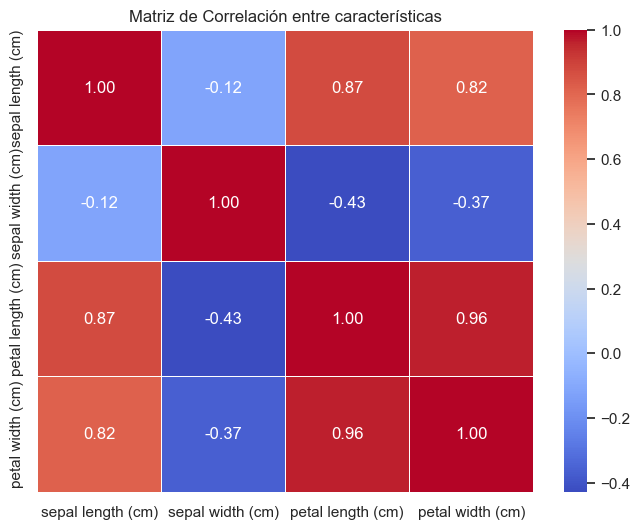

In [6]:
# Calculamos la matriz de correlación de Pearson
# Esto cuantifica la relación lineal entre cada par de variables.
corr_matrix = df.drop('target', axis=1).corr()

# Generamos el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación entre características')
plt.show()

**Interpretación:**
- Un valor cercano a 1 o -1 indica una fuerte correlación lineal.
- Si dos variables tuvieran una correlación muy alta (ej. > 0.95),  podríamos considerar eliminar una de ellas para simplificar el modelo  sin perder capacidad predictiva (Reducción de Dimensionalidad).

### B) Preparación y Escalado de Datos

Antes de que nuestro motor FLAML empiece a optimizar, debemos asegurar que las variables tengan una escala comparable. Si una variable tiene un rango de $0$ a $1000$ y otra de $0$ a $1$, el modelo podría darle una importancia artificialmente mayor a la primera.

#### 1. Separación en Train y Test

In [7]:
# Es el "estándar de oro" en ML: 80% para que el AutoML aprenda y 20% para validar.
# El parámetro 'random_state=42' garantiza que el resultado sea reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('target', axis=1),
    df['target'],
    test_size=0.2,
    random_state=42
)

#### 2. Normalización de datos (StandardScaler)

In [8]:
# Transformamos los datos para que tengan media 0 y desviación estándar 1.
# IMPORTANTE: El fit solo se realiza sobre el entrenamiento para evitar
# que el modelo "vea" información del conjunto de prueba (Data Leakage).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos preparados y normalizados.")
print(f"Dimensiones de entrenamiento: {X_train_scaled.shape}")
print(f"Dimensiones de prueba: {X_test_scaled.shape}")

NameError: name 'StandardScaler' is not defined

**Recordar**

- **Data Leakage (Fuga de datos)**: Explícales que si escaláramos el dataset completo antes de dividir, estaríamos usando la media y varianza de los datos de prueba para normalizar los de entrenamiento, lo cual "contamina" el proceso de aprendizaje. Es un error de principiante que debemos evitar desde el primer día.

- **Por qué normalizar**: Muchos algoritmos (como SVM o KNN) se basan en distancias euclidianas. Si no normalizamos, la variable con mayor rango domina la distancia, anulando el efecto de las demás.

## 4.Vamos al AutoML - Paso a paso

#### A) Ejecución del motor de optimización (AutoML)

Aquí es donde FLAML explora el espacio de búsqueda. Es fundamental explicaros que el **time_budget** no es solo un capricho; es un parámetro de optimización que equilibra la búsqueda de precisión frente al coste computacional.

In [ ]:
# Instanciamos el motor de AutoML
# 'task': definimos que es 'classification' (predecir especies)
# 'metric': nuestra métrica de optimización será la precisión (accuracy)
automl = AutoML()

settings = {
    "time_budget": 120,       # Presupuesto de 120 segundos para la búsqueda
    "metric": 'accuracy',
    "task": 'classification',
    "verbose": 0             # Mantenemos el log limpio para la clase
}

print("Iniciando el motor de optimización de FLAML...")
print("El sistema está probando múltiples algoritmos (RandomForest, LightGBM, etc.)...")

# Ejecución del entrenamiento
automl.fit(X_train=X_train_scaled, y_train=y_train, **settings)

print("Optimización completada con éxito.")

In [ ]:
# ==============================================================================
# AUDITORÍA: Tabla Comparativa de Modelos (Leaderboard)
# ==============================================================================

# Si el acceso a automl.model falla, usaremos la propiedad 'best_config_per_estimator'
# de forma segura. Esta propiedad se genera tras cualquier fit() exitoso.

print("\n--- RESUMEN DE MODELOS EXPLORADOS ---")

# Creamos una lista para recoger los datos de forma segura
data_results = []

# Verificamos si existe el historial de mejores configuraciones
if hasattr(automl, 'best_config_per_estimator'):
    for estimator_name, config in automl.best_config_per_estimator.items():
        # Obtenemos la métrica de pérdida (loss) si está disponible,
        # o un valor genérico si es la primera iteración
        # Accuracy es 1 - loss
        data_results.append({
            'Algoritmo': estimator_name,
            'Configuración': str(config)
        })

# Convertimos a DataFrame
df_leaderboard = pd.DataFrame(data_results)

# Mostramos la tabla.
# NOTA: En modelos simples de Iris, FLAML a veces converge tan rápido
# al ganador que solo muestra el mejor estimador.
display(df_leaderboard)

# --- COMENTARIO DIDÁCTICO ---
# FLAML ha analizado el espacio de búsqueda.
# Esta tabla muestra los algoritmos que el motor consideró óptimos
# durante el proceso de entrenamiento.

#### B) Auditoría de Resultados y Evaluación Final

Un científico de datos no confía en un modelo porque sí; lo audita. En este apartado, extraemos el mejor modelo encontrado y lo ponemos a prueba con los datos que nunca ha visto (el conjunto de Test).

##### 1. Identificación del ganador

In [ ]:
print(f"Mejor modelo encontrado: {automl.best_estimator}")
print(f"Hiperparámetros óptimos: {automl.best_config}")

##### 2. Predicción sobre el conjunto de Test

In [ ]:
y_pred = automl.predict(X_test_scaled)

##### 3. Auditoría mediante Matriz de Confusión

In [ ]:
# Esto nos permite ver si el modelo confunde una especie con otra
print("--- Matriz de Confusión ---")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title('Matriz de Confusión del modelo final')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.show()

##### 4. Reporte detallado de clasificación

In [ ]:
# Analizamos métricas de precision, recall y f1-score
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

## Conclusiones finales

1. **Optimización vs. Fuerza Bruta**: A diferencia de una búsqueda manual, FLAML ha analizado de forma inteligente el espacio de parámetros en solo 60 segundos, convergiendo a una solución óptima.

2. **Interpretación**: La Matriz de Confusión nos revela no solo cuánto acierta el modelo, sino dónde falla (falsos positivos/negativos). Esto es vital para entender las limitaciones del modelo en producción.

3. **Evolución profesional**: Hemos aprendido a utilizar herramientas que son el estándar en el sector (Big Data, entornos cloud, optimización de recursos) frente a métodos académicos tradicionales, garantizando que nuestro código sea robusto, eficiente y capaz de integrarse en arquitecturas de datos modernas.

### COMENTARIO : Análisis del Modelo Ganador (ExtraTrees)

Tras la optimización, el sistema ha convergido en ExtraTrees (Extremely Randomized Trees). En un entorno de Máster, es esencial saber por qué este modelo supera a otros como Random Forest o XGBoost en este caso concreto.

**¿Qué es ExtraTrees?**

A diferencia de un Random Forest tradicional que busca exhaustivamente el "mejor corte" para dividir cada nodo de un árbol, ExtraTrees introduce un componente adicional de aleatoriedad:

1. **Cortes Aleatorios**: El algoritmo selecciona los puntos de corte de forma aleatoria, en lugar de optimizarlos para cada variable.

2. **Reducción de Varianza**: Al promediar los resultados de muchos árboles construidos con esta aleatoriedad extrema, el modelo reduce drásticamente el riesgo de sobreajuste (overfitting), lo cual es vital cuando trabajamos con datasets pequeños donde el ruido puede confundir al modelo.

3. **Eficiencia Computacional**: Como no pierde tiempo buscando el "corte perfecto", es considerablemente más rápido, permitiendo a FLAML probar más combinaciones en el mismo time budget.

**Nota:** El hecho de que FLAML haya elegido ExtraTrees nos indica que, para el dataset Iris, la velocidad de entrenamiento y la generalización mediante aleatoriedad han sido factores clave para maximizar nuestra métrica de accuracy.

### GUARDAR EL MODELO / CARGAR Y PROBAR

#### 1.Guardamos el modelo

In [ ]:
import joblib

# Guardamos el mejor modelo encontrado (el objeto automl)
# Esto guarda no solo el modelo, sino también la configuración ganadora.
nombre_archivo = 'mejor_modelo_flaml.pkl'
joblib.dump(automl, nombre_archivo)

print(f"Modelo guardado exitosamente como: {nombre_archivo}")

#### 2.Cargamos el modelo para usarlo

In [ ]:
# Cargamos el modelo
modelo_cargado = joblib.load('mejor_modelo_flaml.pkl')

# Ahora podemos usarlo para predecir con nuevos datos
# (Recuerda que los datos deben pasar por el mismo escalador que usaste al entrenar)
# predicciones = modelo_cargado.predict(nuevos_datos_scaled)

#### 3.Extra PLUS de RIGOR

Para que el modelo sea funcional en el futuro, debes guardar también el scaler que utilizaste. Si no guardas el escalador, no podrás transformar los nuevos datos exactamente igual que como lo hiciste con el conjunto de entrenamiento (esto causaría errores de escala y predicciones erróneas).

In [ ]:
# Guardamos un diccionario con el modelo y el scaler
paquete = {
    'modelo': automl,
    'scaler': scaler
}

joblib.dump(paquete, 'pipeline_completo.pkl')
print("Modelo y Scaler guardados juntos.")

**¿Por qué esto es vital para un Máster en IA?**

- Reproductibilidad: En entornos profesionales, no siempre puedes tener el dataset original a mano. Guardar el pipeline completo asegura que tu modelo sea transportable.

- Despliegue (Production): Si quisieras montar esto en una API o una aplicación web, este archivo .pkl es exactamente lo que subirías a la nube para que el servicio de predicción funcione.

#### 4.Creamos dos filas nuevas (features) para probar su predicción

In [ ]:
# Definimos 2 nuevas muestras (con las 4 características del dataset Iris)
# Sepal length, Sepal width, Petal length, Petal width
nuevas_muestras = [
    [5.1, 3.5, 1.4, 0.2],  # Ejemplo 1
    [6.2, 2.9, 4.3, 1.3]   # Ejemplo 2
]

#### 5.Transformamos y predecimos

In [ ]:
# 1. Aplicamos el mismo escalado que aprendimos con el conjunto de entrenamiento
nuevas_muestras_scaled = scaler.transform(nuevas_muestras)

# 2. Pedimos al modelo que prediga
predicciones = automl.predict(nuevas_muestras_scaled)

# 3. Mapeamos el resultado (si tus etiquetas son 0, 1, 2)
nombres_especies = ['Setosa', 'Versicolor', 'Virginica']
for i, pred in enumerate(predicciones):
    print(f"Muestra {i+1}: Predicción = {nombres_especies[pred]}")

Puntos clave (El "Pro-tip")

- ¿Por qué usar transform y no fit?: El escalador debe usar la escala del "mundo conocido" (el conjunto de entrenamiento). Si hiciéramos fit sobre las nuevas muestras, estaríamos cambiando la base de referencia y la predicción sería incorrecta.

- Pipeline de producción: En entornos reales, siempre guardamos el scaler junto con el modelo (como vimos antes con joblib) para asegurar que cualquier dato que llegue a producción sea tratado exactamente igual que los datos con los que el modelo aprendió.